In [2]:
# =============================================================================
# Zelle 01 – Setup & Datenladen (EDA Modell B)
# =============================================================================
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

df_b = pd.read_csv("../data/raw/model_b_raw.csv")

X_B_MERKMALE = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                 "wandtyp", "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
Y_B_MERKMALE = ["schneckendrehzahl", "massetemperatur", "duesenspalt",
                 "kalibrierdruck", "kuehlwassertemperatur"]

print(f"Datensatz: {df_b.shape}")
print(f"X_B ({len(X_B_MERKMALE)}): {X_B_MERKMALE}")
print(f"Y_B ({len(Y_B_MERKMALE)}): {Y_B_MERKMALE}")
print(f"\nErste Zeilen:")
print(df_b.head())

Datensatz: (2000, 13)
X_B (7): ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung']
Y_B (5): ['schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'kalibrierdruck', 'kuehlwassertemperatur']

Erste Zeilen:
   material_mfr     dn_ziel  wandstaerke_soll  dickentoleranz       wandtyp  \
0      0.760943  104.164565          1.385443        0.055494     einwandig   
1      0.492003  158.608859          2.350657        0.295226  doppelwandig   
2      0.850090  123.340827          1.836205        0.114787     einwandig   
3      0.888113  225.335978          2.589429        0.198277     einwandig   
4      0.309793   72.773106          1.553914        0.125063     einwandig   

   produktionsgeschwindigkeit_soll  ovalitaet_anforderung  \
0                         9.400096               0.441754   
1                        10.168837               0.353945   
2                        10.907655               0.

In [3]:
# =============================================================================
# Zelle 02 – Deskriptive Statistik (numerische X_B/Y_B-Merkmale)
# =============================================================================
numerische_merkmale = [c for c in X_B_MERKMALE + Y_B_MERKMALE if c != "wandtyp"]

deskriptiv = df_b[numerische_merkmale].describe().T
deskriptiv["skewness"] = df_b[numerische_merkmale].skew()
deskriptiv["kurtosis"] = df_b[numerische_merkmale].kurt()

shapiro_ergebnisse = []
for col in numerische_merkmale:
    stat, p = stats.shapiro(df_b[col].sample(min(len(df_b), 5000), random_state=SEED))
    shapiro_ergebnisse.append({"merkmal": col, "shapiro_p": round(p, 5), "normalverteilt": p > 0.05})

shapiro_df = pd.DataFrame(shapiro_ergebnisse).set_index("merkmal")
deskriptiv = deskriptiv.join(shapiro_df)

print(deskriptiv.round(3).to_string())
deskriptiv.to_csv("../reports/tables/09_deskriptive_statistik_model_b.csv")

                                  count     mean     std      min      25%      50%      75%      max  skewness  kurtosis  shapiro_p  normalverteilt
material_mfr                     2000.0    0.691   0.196    0.300    0.556    0.696    0.820    1.336     0.095    -0.266      0.000           False
dn_ziel                          2000.0  143.859  61.740   50.000   96.089  132.313  176.674  315.000     0.935     0.479      0.000           False
wandstaerke_soll                 2000.0    2.149   0.515    1.132    1.764    2.056    2.447    3.816     0.771     0.208      0.000           False
dickentoleranz                   2000.0    0.175   0.073    0.050    0.110    0.176    0.236    0.300    -0.015    -1.203      0.000           False
produktionsgeschwindigkeit_soll  2000.0   10.396   2.459    2.460    8.827   10.333   12.001   17.000    -0.052     0.045      0.041           False
ovalitaet_anforderung            2000.0    0.653   0.205    0.300    0.472    0.663    0.832    1.000    -

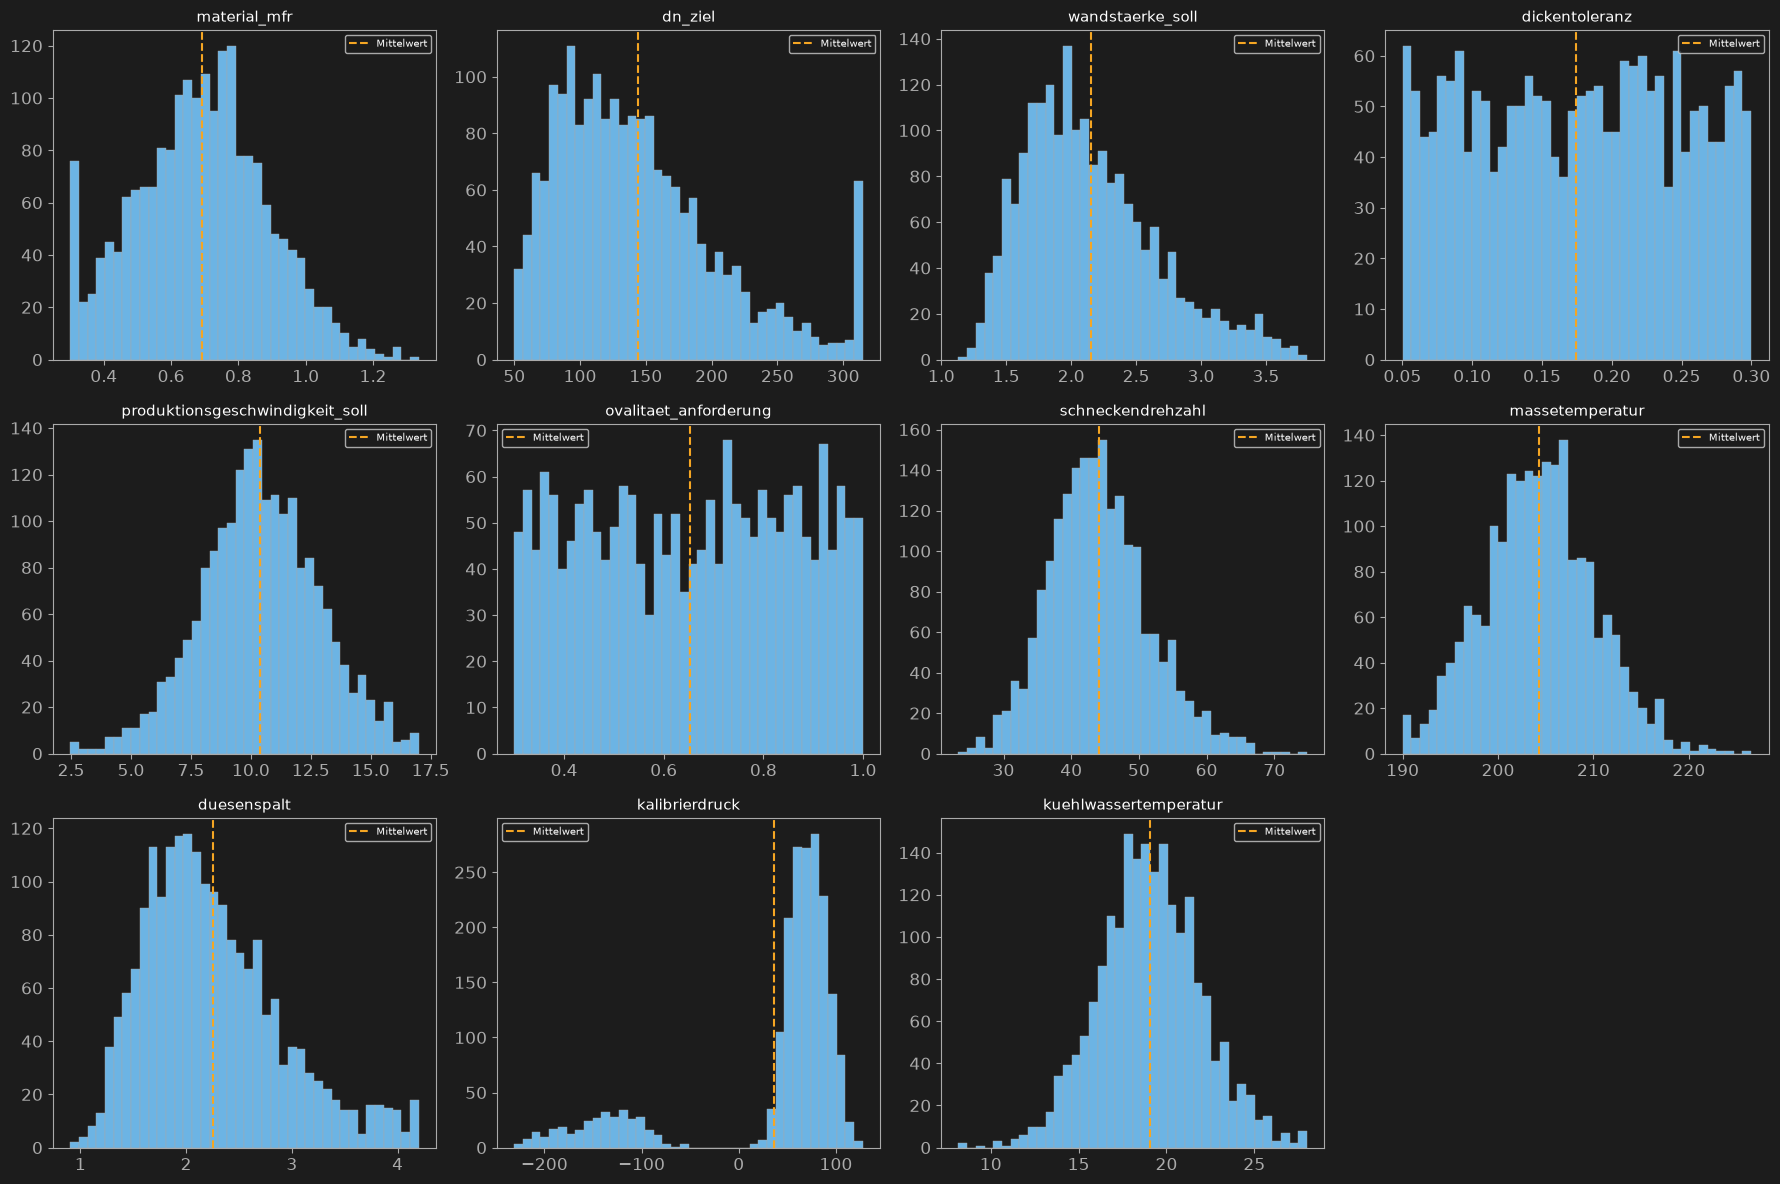

In [4]:
# =============================================================================
# Zelle 03 – Verteilungs-Histogramme aller numerischen X_B/Y_B-Merkmale
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerische_merkmale):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# Leere Subplots ausblenden (12 Slots, 11 Merkmale)
for ax in axes[len(numerische_merkmale):]:
    ax.axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_model_b.png")
plt.show()

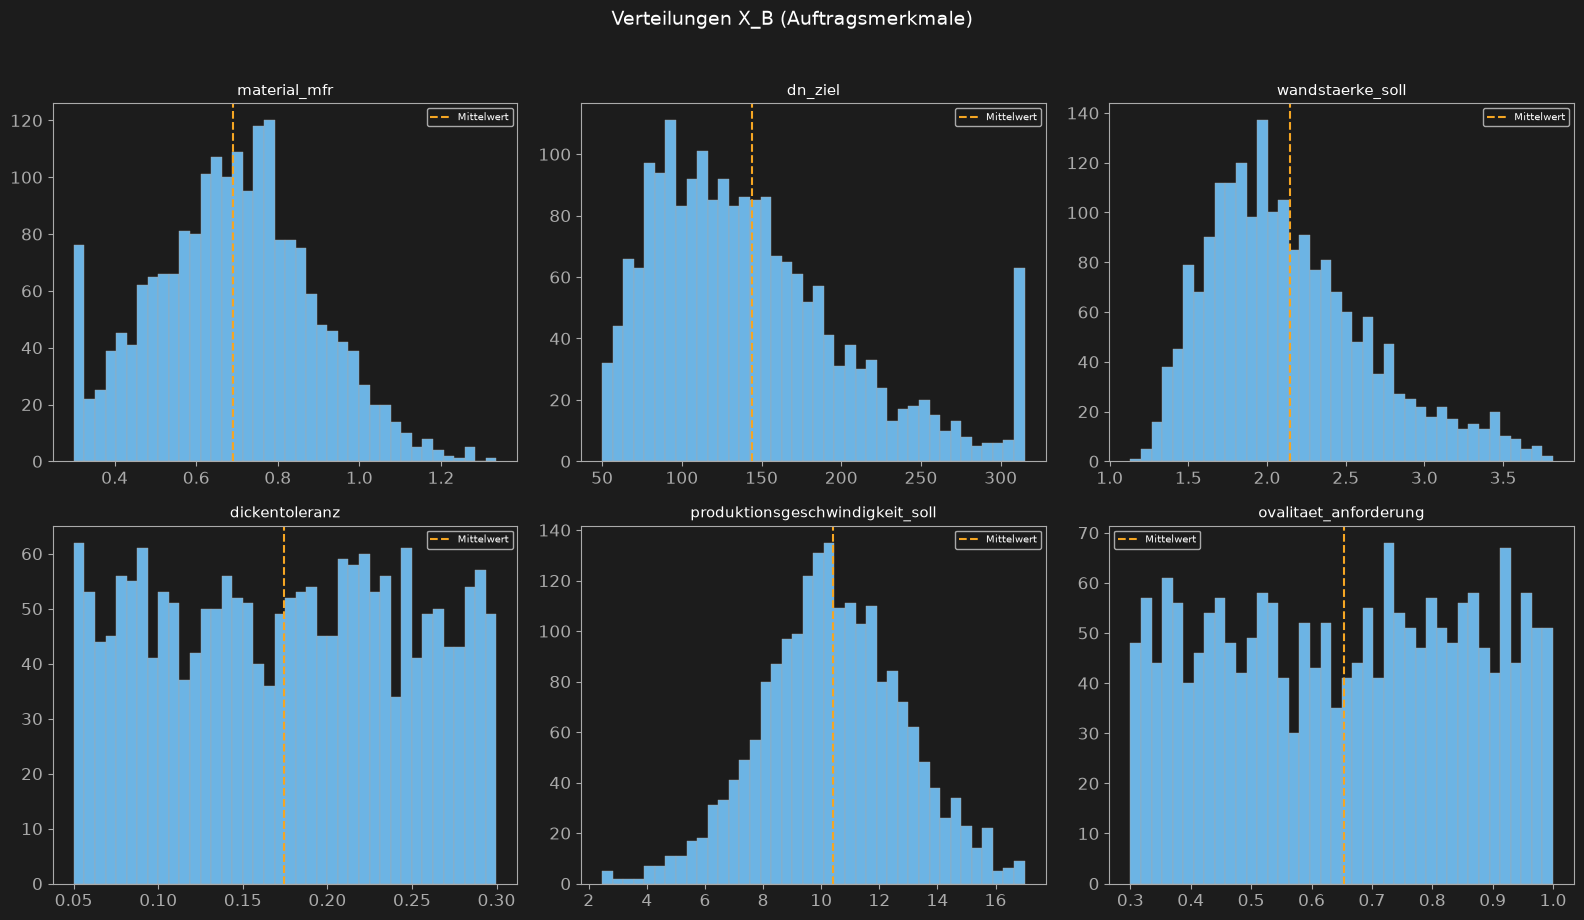

In [5]:
# =============================================================================
# Zelle 03a – Verteilungs-Histogramme X_B (Auftragsmerkmale)
# =============================================================================
x_b_numerisch = [c for c in X_B_MERKMALE if c != "wandtyp"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, x_b_numerisch):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(x_b_numerisch):]:
    ax.axis("off")

fig.suptitle("Verteilungen X_B (Auftragsmerkmale)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_x_b.png")
plt.show()

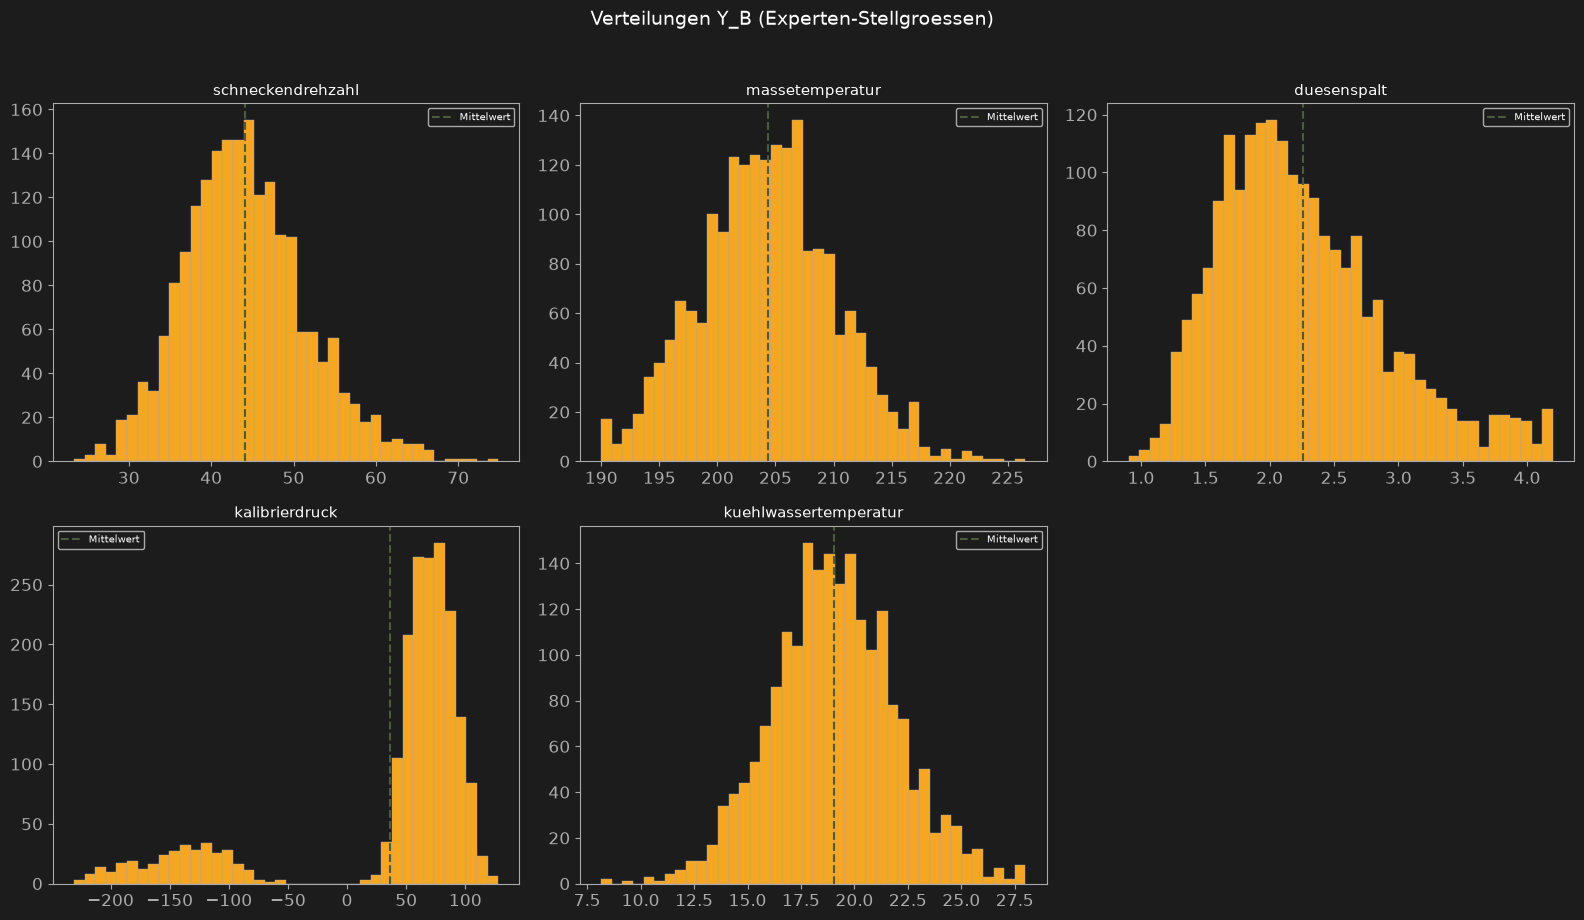

In [6]:
# =============================================================================
# Zelle 03b – Verteilungs-Histogramme Y_B (Experten-Stellgroessen)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, Y_B_MERKMALE):
    ax.hist(df_b[col], bins=40, color=COLOR_GOLD, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GREEN, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(Y_B_MERKMALE):]:
    ax.axis("off")

fig.suptitle("Verteilungen Y_B (Experten-Stellgroessen)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_y_b.png")
plt.show()

Formluft  : n=1668, mean=  71.91, std= 18.63, Shapiro-p=0.00118, normalverteilt=False
Vakuum    : n= 332, mean=-141.12, std= 37.88, Shapiro-p=0.00010, normalverteilt=False


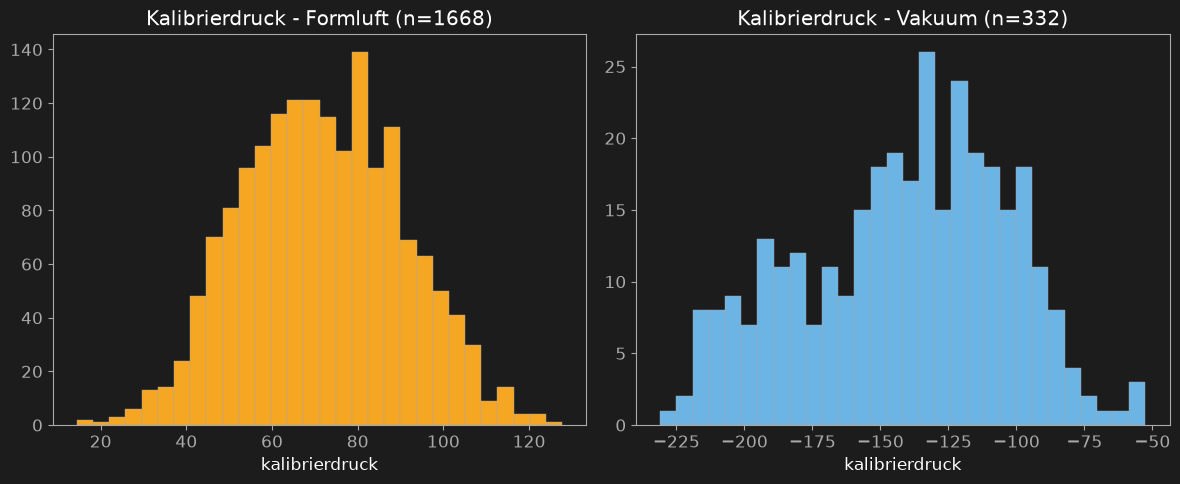

In [7]:
# =============================================================================
# Zelle 04 – Kalibrierdruck: Normalitaet getrennt nach Kalibriermechanismus
# =============================================================================
# Prueft die Hypothese: Gesamtverteilung ist bimodal, aber INNERHALB jeder
# Mechanismus-Gruppe (Formluft/Vakuum) sollte die Verteilung naeherungsweise
# normal sein - falls bestaetigt, ist kein separates Modell noetig (die
# modusbestimmende Variable ist bekannt und als Feature vorhanden).
# =============================================================================

for mechanismus in ["Formluft", "Vakuum"]:
    teilmenge = df_b.loc[df_b["kalibriermechanismus"] == mechanismus, "kalibrierdruck"]
    stat, p = stats.shapiro(teilmenge.sample(min(len(teilmenge), 5000), random_state=SEED))
    print(f"{mechanismus:10s}: n={len(teilmenge):4d}, mean={teilmenge.mean():7.2f}, "
          f"std={teilmenge.std():6.2f}, Shapiro-p={p:.5f}, normalverteilt={p > 0.05}")

# --- Visueller Vergleich: Histogramme getrennt ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mechanismus, farbe in zip(axes, ["Formluft", "Vakuum"], [COLOR_GOLD, COLOR_BLUE]):
    teilmenge = df_b.loc[df_b["kalibriermechanismus"] == mechanismus, "kalibrierdruck"]
    ax.hist(teilmenge, bins=30, color=farbe, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.set_title(f"Kalibrierdruck - {mechanismus} (n={len(teilmenge)})")
    ax.set_xlabel("kalibrierdruck")

plt.tight_layout()
save_figure(fig, "../reports/figures/09_kalibrierdruck_getrennt_nach_mechanismus.png")
plt.show()

## Datenwörterbuch – Modell B (model_b_raw.csv)

| Spalte | Beschreibung | Einheit | Typ |
|---|---|---|---|
| material_mfr | Schmelzindex der Materialcharge | g/10min | kontinuierlich |
| dn_ziel | Ziel-Nennweite des Rohrs | mm | kontinuierlich |
| wandstaerke_soll | Geforderte Wandstärke | mm | kontinuierlich |
| dickentoleranz | Zulässige Abweichung von der Sollwandstärke | mm | kontinuierlich |
| wandtyp | Rohrkonstruktion | – | kategorial (einwandig/doppelwandig) |
| produktionsgeschwindigkeit_soll | Geforderte Produktionsgeschwindigkeit | m/min | kontinuierlich |
| ovalitaet_anforderung | Zulässige Rundheitsabweichung | % | kontinuierlich |
| kalibriermechanismus | Art der Kalibrierung | – | kategorial (Formluft/Vakuum) |
| schneckendrehzahl | Gewählte Schneckendrehzahl | U/min | kontinuierlich, **Zielgröße (Y_B)** |
| massetemperatur | Gewählte Massetemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |
| duesenspalt | Gewählter Düsenspalt | mm | kontinuierlich, **Zielgröße (Y_B)** |
| kalibrierdruck | Gewählter Kalibrierdruck | mbar | kontinuierlich, **Zielgröße (Y_B)** |
| kuehlwassertemperatur | Gewählte Kühlwassertemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |

**X_B (7 Eingabemerkmale):** material_mfr, dn_ziel, wandstaerke_soll, dickentoleranz, wandtyp, produktionsgeschwindigkeit_soll, ovalitaet_anforderung

**Y_B (5 Zielgrößen):** schneckendrehzahl, massetemperatur, duesenspalt, kalibrierdruck, kuehlwassertemperatur

In [9]:
# =============================================================================
# Zelle 06 – AP 0.1: Blinde erste Sichtung (wie ein Analyst ohne Vorwissen)
# =============================================================================
print(f"Shape: {df_b.shape}")
print(f"\nSpalten:\n{df_b.columns.tolist()}")
print(f"\nDatentypen:\n{df_b.dtypes}")
df_b.head()

Shape: (2000, 13)

Spalten:
['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'kalibriermechanismus', 'schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'kalibrierdruck', 'kuehlwassertemperatur']

Datentypen:
material_mfr                       float64
dn_ziel                            float64
wandstaerke_soll                   float64
dickentoleranz                     float64
wandtyp                             object
produktionsgeschwindigkeit_soll    float64
ovalitaet_anforderung              float64
kalibriermechanismus                object
schneckendrehzahl                  float64
massetemperatur                    float64
duesenspalt                        float64
kalibrierdruck                     float64
kuehlwassertemperatur              float64
dtype: object


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,wandtyp,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,kalibriermechanismus,schneckendrehzahl,massetemperatur,duesenspalt,kalibrierdruck,kuehlwassertemperatur
0,0.760943,104.164565,1.385443,0.055494,einwandig,9.400096,0.441754,Formluft,33.691143,200.906186,1.434323,59.946878,19.783884
1,0.492003,158.608859,2.350657,0.295226,doppelwandig,10.168837,0.353945,Formluft,43.847410,199.855728,2.346622,80.505641,19.459041
2,0.850090,123.340827,1.836205,0.114787,einwandig,10.907655,0.784632,Formluft,45.499866,210.933172,1.929061,86.715031,16.953516
3,0.888113,225.335978,2.589429,0.198277,einwandig,6.963402,0.734473,Vakuum,46.943818,208.291018,2.655661,-111.869242,21.110659
4,0.309793,72.773106,1.553914,0.125063,einwandig,12.279022,0.882630,Formluft,36.970557,190.000000,1.597350,51.677607,19.647650


In [10]:
# =============================================================================
# Zelle 07 – AP 1.3 + 1.4: Fehlende Werte-Check + IQR-Ausreisser-Analyse
# =============================================================================
print("=== AP 1.3: Fehlende Werte ===")
print(df_b.isna().sum())
print(f"\nDatensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken "
      f"generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um "
      f"Fokus auf die X_B->Y_B-Beziehung selbst zu legen.")

print("\n=== AP 1.4: IQR-Ausreisser je numerischer Variable ===")
numerische_merkmale = [c for c in df_b.columns if df_b[c].dtype != "object"]

ausreisser_ergebnisse = []
for col in numerische_merkmale:
    q1, q3 = df_b[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    untere_grenze, obere_grenze = q1 - 1.5*iqr, q3 + 1.5*iqr
    ausreisser = df_b[(df_b[col] < untere_grenze) | (df_b[col] > obere_grenze)]
    ausreisser_ergebnisse.append({
        "merkmal": col, "q1": round(q1,3), "q3": round(q3,3), "iqr": round(iqr,3),
        "untere_grenze": round(untere_grenze,3), "obere_grenze": round(obere_grenze,3),
        "n_ausreisser": len(ausreisser), "anteil_prozent": round(len(ausreisser)/len(df_b)*100, 2)
    })

ausreisser_df = pd.DataFrame(ausreisser_ergebnisse)
print(ausreisser_df.to_string(index=False))
ausreisser_df.to_csv("../reports/tables/09_iqr_ausreisser_model_b.csv", index=False)
print("\nGespeichert: reports/tables/09_iqr_ausreisser_model_b.csv")

=== AP 1.3: Fehlende Werte ===
material_mfr                       0
dn_ziel                            0
wandstaerke_soll                   0
dickentoleranz                     0
wandtyp                            0
produktionsgeschwindigkeit_soll    0
ovalitaet_anforderung              0
kalibriermechanismus               0
schneckendrehzahl                  0
massetemperatur                    0
duesenspalt                        0
kalibrierdruck                     0
kuehlwassertemperatur              0
dtype: int64

Datensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um Fokus auf die X_B->Y_B-Beziehung selbst zu legen.

=== AP 1.4: IQR-Ausreisser je numerischer Variable ===
                        merkmal      q1      q3    iqr  untere_grenze  obere_grenze  n_ausreisser  anteil_prozent
                   material_mfr   0.556   0.820  0.264          0.160         1.216             8            0.40
         

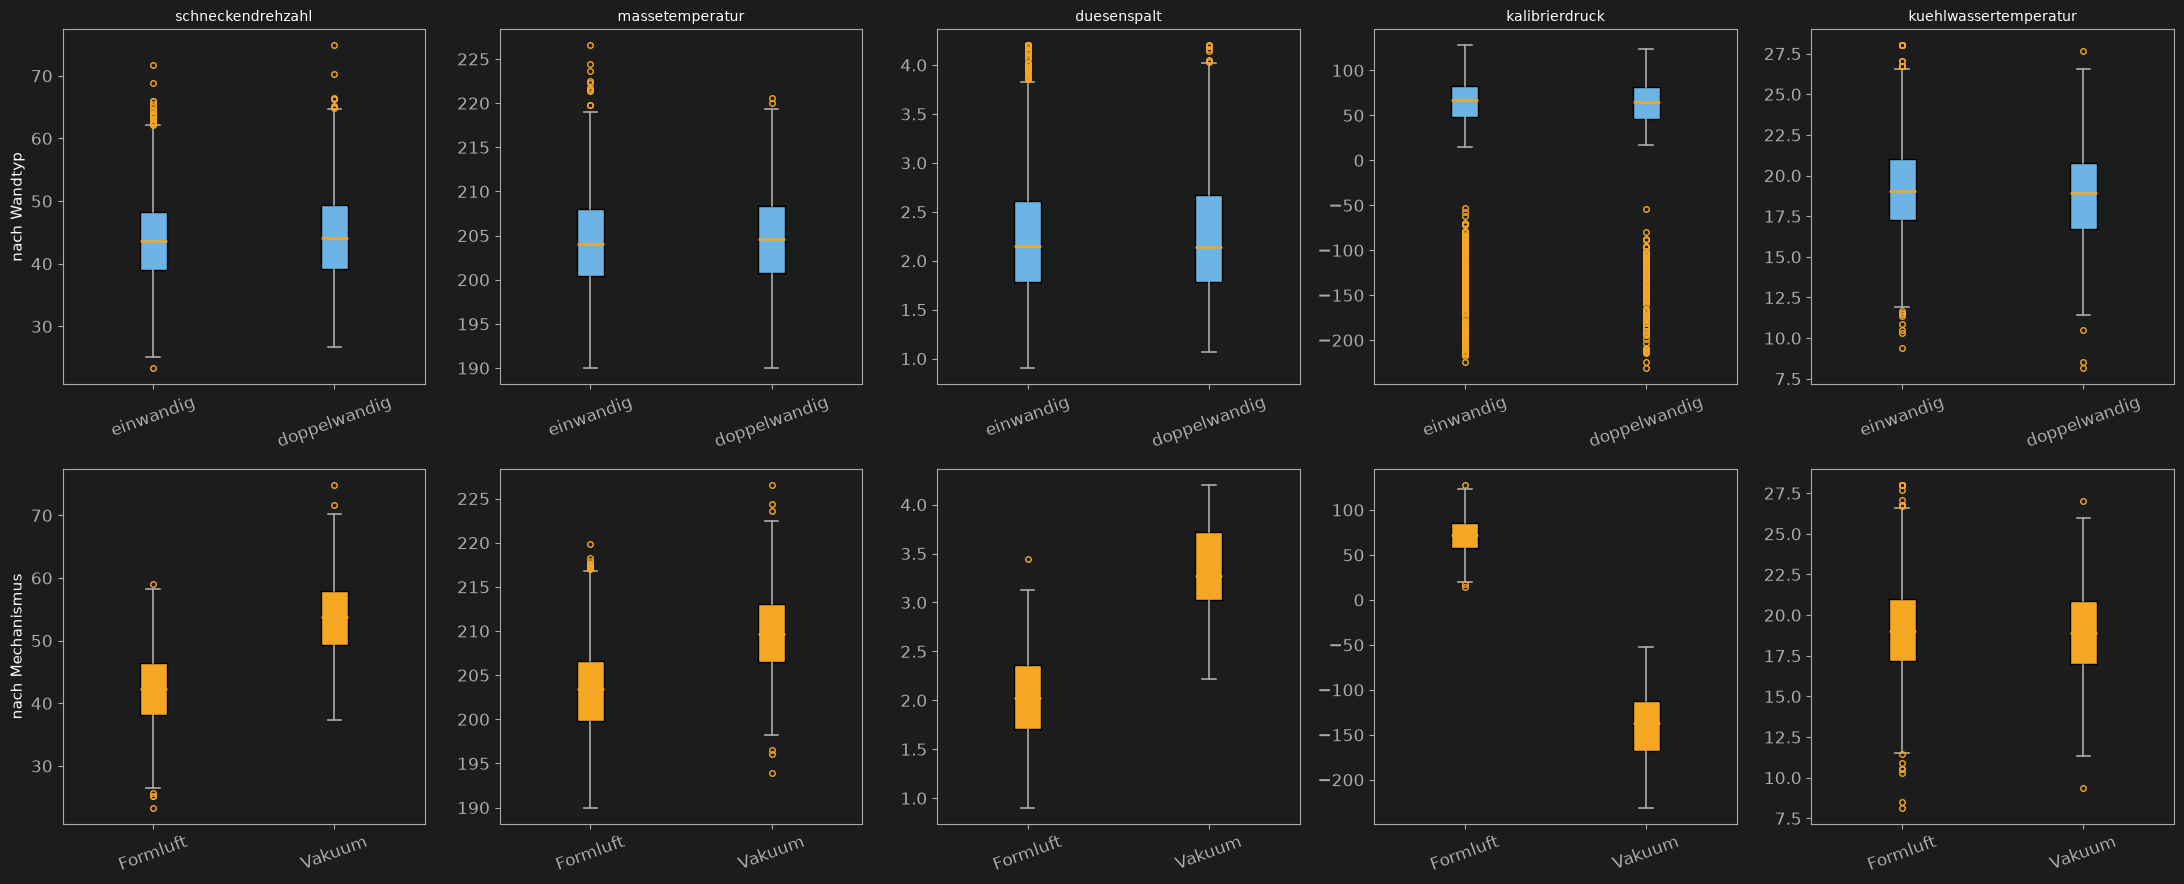

In [11]:
# =============================================================================
# Zelle 08 – AP 2.5 (vorgezogen): Boxplots Y_B nach Wandtyp und Mechanismus
# =============================================================================
# Vorgezogen aus der urspruenglichen AP-Reihenfolge, da direkt an die
# Kalibrierdruck-Ausreisser-Diskussion (Zelle 07) anschliesst - bestaetigt
# visuell, dass die "Ausreisser" bei kalibrierdruck strukturell durch die
# Mechanismus-Gruppe erklaert sind, kein echtes Datenproblem.
# =============================================================================

Y_B_MERKMALE = ["schneckendrehzahl", "massetemperatur", "duesenspalt", "kalibrierdruck", "kuehlwassertemperatur"]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for i, y_col in enumerate(Y_B_MERKMALE):
    # Zeile 1: nach Wandtyp
    daten_wandtyp = [df_b[df_b["wandtyp"]==w][y_col].values for w in ["einwandig", "doppelwandig"]]
    bp1 = axes[0,i].boxplot(daten_wandtyp, tick_labels=["einwandig","doppelwandig"], patch_artist=True, **BOXPLOT_STYLE)
    for box in bp1["boxes"]:
        box.set_facecolor(COLOR_BLUE)
    axes[0,i].set_title(y_col, fontsize=10)
    axes[0,i].tick_params(axis="x", rotation=20)

    # Zeile 2: nach Mechanismus
    daten_mech = [df_b[df_b["kalibriermechanismus"]==m][y_col].values for m in ["Formluft", "Vakuum"]]
    bp2 = axes[1,i].boxplot(daten_mech, tick_labels=["Formluft","Vakuum"], patch_artist=True, **BOXPLOT_STYLE)
    for box in bp2["boxes"]:
        box.set_facecolor(COLOR_GOLD)
    axes[1,i].tick_params(axis="x", rotation=20)

axes[0,0].set_ylabel("nach Wandtyp", fontsize=11)
axes[1,0].set_ylabel("nach Mechanismus", fontsize=11)

plt.tight_layout()
save_figure(fig, "../reports/figures/09_boxplots_y_b_nach_gruppen.png")
plt.show()

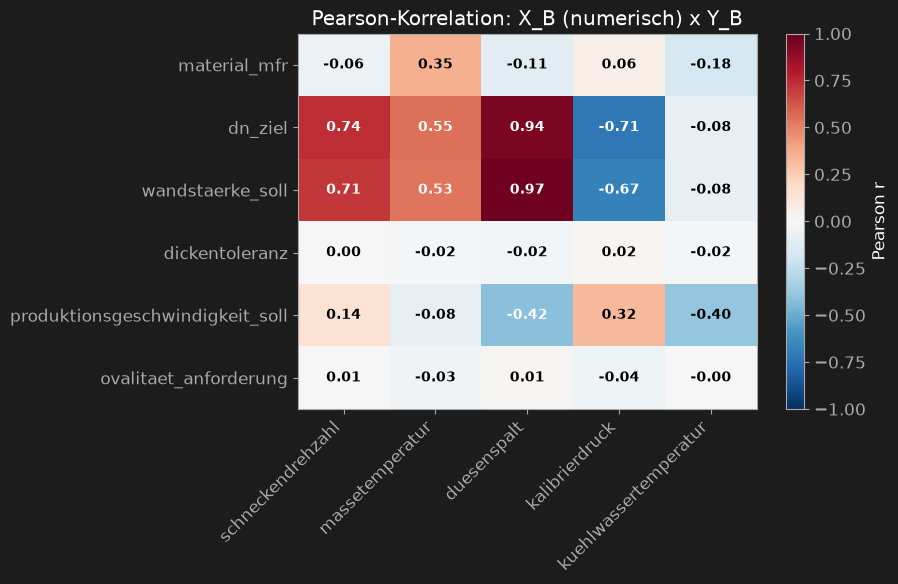

In [14]:
# =============================================================================
# Zelle 09 – AP 2.1 (KORRIGIERT): Textfarbe je nach Zellwert (dunkel/hell)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pearson_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = pearson_matrix.values[i, j]
        # Dunkle Schrift bei hellem Zellhintergrund (Werte nahe 0), helle Schrift bei starker Faerbung
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Pearson r")
plt.title("Pearson-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pearson_heatmap_x_b_y_b.png")
plt.show()

                                 schneckendrehzahl  massetemperatur  duesenspalt  kalibrierdruck  kuehlwassertemperatur
material_mfr                                -0.045            0.337       -0.106           0.034                 -0.177
dn_ziel                                      0.695            0.521        0.924          -0.000                 -0.074
wandstaerke_soll                             0.662            0.510        0.965          -0.029                 -0.076
dickentoleranz                               0.009           -0.019       -0.021           0.015                 -0.029
produktionsgeschwindigkeit_soll              0.151           -0.081       -0.391           0.075                 -0.371
ovalitaet_anforderung                        0.009           -0.031        0.009          -0.178                 -0.003


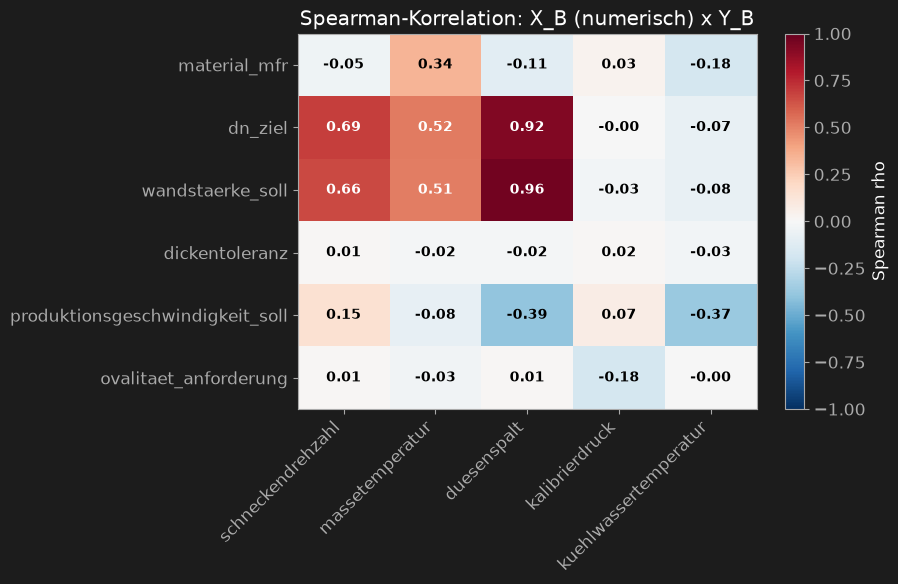


=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===
dn_ziel                          kalibrierdruck       0.711735
wandstaerke_soll                 kalibrierdruck       0.645414
produktionsgeschwindigkeit_soll  kalibrierdruck       0.245696
ovalitaet_anforderung            kalibrierdruck       0.132790
wandstaerke_soll                 schneckendrehzahl    0.047379
dtype: float64


In [15]:
# =============================================================================
# Zelle 10 – AP 2.2: Spearman-Korrelationsmatrix (X_B numerisch x Y_B)
# =============================================================================
# Ergaenzt Pearson (nur lineare Zusammenhaenge) um monotone, auch
# nichtlineare Beziehungen - relevant v.a. fuer kalibrierdruck, wo der
# Formluft/Vakuum-Sprung vermutlich von Spearman staerker erfasst wird.
# =============================================================================

spearman_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        spearman_matrix.loc[x_col, y_col] = df_b[x_col].corr(df_b[y_col], method="spearman")

print(spearman_matrix.round(3).to_string())
spearman_matrix.to_csv("../reports/tables/09_spearman_korrelation_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(spearman_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = spearman_matrix.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Spearman rho")
plt.title("Spearman-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_spearman_heatmap_x_b_y_b.png")
plt.show()

# --- Direkter Vergleich Pearson vs. Spearman: wo weichen sie am staerksten ab? ---
differenz = (spearman_matrix.astype(float) - pearson_matrix.astype(float)).abs()
print("\n=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===")
print(differenz.stack().sort_values(ascending=False).head(5))

                                 schneckendrehzahl  massetemperatur  duesenspalt  kalibrierdruck  kuehlwassertemperatur
material_mfr                                 0.000            0.082        0.000           0.000                  0.025
dn_ziel                                      0.393            0.204        1.025           0.879                  0.042
wandstaerke_soll                             0.394            0.182        1.407           0.666                  0.013
dickentoleranz                               0.000            0.000        0.000           0.000                  0.000
produktionsgeschwindigkeit_soll              0.060            0.022        0.102           0.096                  0.091
ovalitaet_anforderung                        0.006            0.000        0.000           0.026                  0.000


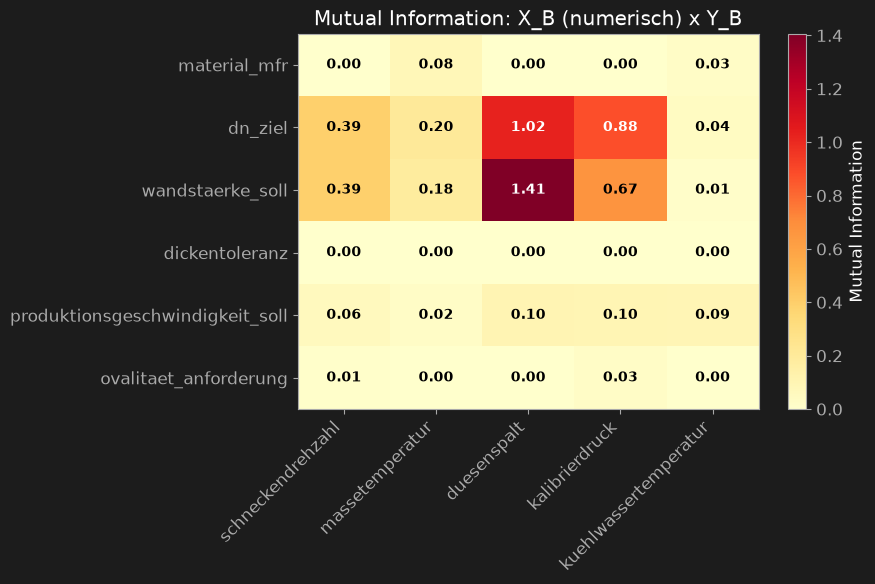


=== Kalibrierdruck: Vergleich der drei Methoden ===
                                 pearson_abs  spearman_abs  mutual_info
material_mfr                           0.058         0.034        0.000
dn_ziel                                0.712         0.000        0.879
wandstaerke_soll                       0.674         0.029        0.666
dickentoleranz                         0.020         0.015        0.000
produktionsgeschwindigkeit_soll        0.321         0.075        0.096
ovalitaet_anforderung                  0.045         0.178        0.026


In [16]:
# =============================================================================
# Zelle 11 – AP 2.3: Mutual Information (X_B numerisch x Y_B)
# =============================================================================
# Erfasst beliebige statistische Abhaengigkeit, auch nicht-monotone
# Zusammenhaenge (wie den Formluft/Vakuum-Sprung bei kalibrierdruck, den
# weder Pearson noch Spearman angemessen erfassen konnten, siehe Zelle 10).
# =============================================================================
from sklearn.feature_selection import mutual_info_regression

mi_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for y_col in Y_B_MERKMALE:
    mi_werte = mutual_info_regression(df_b[x_b_numerisch], df_b[y_col], random_state=SEED)
    mi_matrix[y_col] = mi_werte

print(mi_matrix.round(3).to_string())
mi_matrix.to_csv("../reports/tables/09_mutual_information_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(mi_matrix.values.astype(float), cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = mi_matrix.values[i, j]
        textfarbe = "black" if wert < mi_matrix.values.max()*0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Mutual Information")
plt.title("Mutual Information: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_mutual_information_heatmap.png")
plt.show()

# --- Vergleich: bestaetigt MI staerkere Kalibrierdruck-Abhaengigkeit als Pearson/Spearman? ---
print("\n=== Kalibrierdruck: Vergleich der drei Methoden ===")
vergleich_kalibrierdruck = pd.DataFrame({
    "pearson_abs": pearson_matrix["kalibrierdruck"].astype(float).abs(),
    "spearman_abs": spearman_matrix["kalibrierdruck"].astype(float).abs(),
    "mutual_info": mi_matrix["kalibrierdruck"],
})
print(vergleich_kalibrierdruck.round(3).to_string())

In [17]:
# =============================================================================
# Zelle 12 – AP 2.4: Kruskal-Wallis-Test (Wandtyp/Mechanismus x Y_B)
# =============================================================================
# Prueft, ob die Gruppenmediane (Wandtyp/Mechanismus) signifikant
# unterschiedliche Y_B-Werte zeigen - formale statistische Absicherung
# der Boxplot-Beobachtungen aus Zelle 08.
# =============================================================================
kw_ergebnisse = []
for gruppierung in ["wandtyp", "kalibriermechanismus"]:
    gruppen_werte = df_b[gruppierung].unique()
    for y_col in Y_B_MERKMALE:
        gruppen_daten = [df_b.loc[df_b[gruppierung]==g, y_col].values for g in gruppen_werte]
        stat, p = stats.kruskal(*gruppen_daten)
        kw_ergebnisse.append({
            "gruppierung": gruppierung, "y_merkmal": y_col,
            "h_statistik": round(stat, 2), "p_wert": round(p, 5), "signifikant": p < 0.05
        })

kw_df = pd.DataFrame(kw_ergebnisse)
print(kw_df.to_string(index=False))
kw_df.to_csv("../reports/tables/09_kruskal_wallis_model_b.csv", index=False)

         gruppierung             y_merkmal  h_statistik  p_wert  signifikant
             wandtyp     schneckendrehzahl         4.57 0.03261         True
             wandtyp       massetemperatur         1.77 0.18389        False
             wandtyp           duesenspalt         0.31 0.57554        False
             wandtyp        kalibrierdruck         1.57 0.20998        False
             wandtyp kuehlwassertemperatur         3.43 0.06405        False
kalibriermechanismus     schneckendrehzahl       536.85 0.00000         True
kalibriermechanismus       massetemperatur       326.79 0.00000         True
kalibriermechanismus           duesenspalt       785.02 0.00000         True
kalibriermechanismus        kalibrierdruck       830.25 0.00000         True
kalibriermechanismus kuehlwassertemperatur         1.34 0.24656        False
